In [1]:
import xarray as xr
import pandas as pd
from scipy import stats
import numpy as np
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from metpy.units import units
import glob,os
from scipy import stats
from scipy.stats import t
from windspharm.xarray import VectorWind
import metpy.calc as mpcalc
from matplotlib.font_manager import FontProperties
%run ../functions/Transfer_longitude.ipynb

ERROR 1: PROJ: proj_create_from_database: Open of /knight/anaconda_aug22/envs/aug22_env/share/proj failed


## Read the data

In [2]:
diri='/zhoulab_rit/lzhuo/data/Modelling/Med_climatology/'
# filename='sf.plev.nc'
# fi=xr.open_dataset(diri+filename)
# # Transfer the longitude
# fi=central180_to_0(fi)
# sf=fi.sf.sel(time=slice('1979-06-01','1979-11-30'),lev_p=900).\
#     mean(dim='time')

filename='Z3.plev.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
Z3=fi.Z3.sel(time=slice('1979-06-01','1979-11-30'),lev_p=900)

In [3]:
filename='pot.plev.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
pot=fi.pot.sel(time=slice('1979-06-01','1979-11-30'),lev_p=900)#.\

In [4]:
filename='U.plev.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
U=fi.U.sel(time=slice('1979-06-01','1979-11-30'),lev_p=900)#.\
#     mean(dim='time')

filename='V.plev.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
V=fi.V.sel(time=slice('1979-06-01','1979-11-30'),lev_p=900)#.\
#     mean(dim='time')

In [5]:
def plot_phi(ax,phi,intervals,phi_line,line_intervals,u,v):
    fontsize=8
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '50m'
    lonE=80
    lonW=-70
    latS=0
    latN=70
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res))
    ax.set_xticks([-60, -30,0,30, 60], crs=ccrs.PlateCarree())
    ax.set_yticks([20,40,60], crs=ccrs.PlateCarree())
    lats=phi.lat
    lons=phi.lon
    # Specify the intervals
#     minVal = 250
#     maxVal = 350+5
#     cint = 5
#     intervals = np.arange(minVal, maxVal, cint)
    CF = ax.contourf(lons,lats,phi,intervals,transform=proj_data,#norm=colors.CenteredNorm(),
                 cmap=plt.get_cmap('bwr'),extend='both')
#     cbar=plt.colorbar(CF,ax=ax,orientation="horizontal",aspect=50)
#     cbar.ax.tick_params(axis="x",labelsize=8,pad=1)
    lines = ax.contour(lons,lats,phi_line,line_intervals,colors=[(0.0,1.0,0.0)],linestyles='solid', linewidths=1.5,transform=proj_data)
    cl=ax.clabel(lines, fontsize=10, levels=np.array([1040,1060,1080,1100]),colors='k',fmt='%3.2f', inline=True,zorder=2)
    for txt in cl:
        txt.set_bbox(dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.7,   # 0.6–0.8 都很好
            pad=0.2
        ))
    Q = ax.quiver(lons[::2], lats[::2], u[::2,::2], v[::2,::2], color='black',units='xy',width=0.5,
                  scale=1,scale_units='xy',transform=proj_data)
    ax.quiverkey(Q, X=0.9, Y=-0.15, U=5,   # U=1 means "1 unit" length in data
             label="5 $m s^{-1}$", labelpos='E',fontproperties=FontProperties(size=8))
#     nx, ny = np.meshgrid(phi.lon, phi.lat)
#     area = np.where(phi.isnull())
#     sig1 = ax.scatter(nx[area], ny[area],  s = 1.5, c = 'gray', transform = ccrs.PlateCarree())
#     ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
#     ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

def plot_phi_line(ax,phi,intervals,phi_line,line_intervals,u,v):
    fontsize=8
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '50m'
    lonE=80
    lonW=-70
    latS=0
    latN=70
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res))
    ax.set_xticks([-60, -30,0,30, 60], crs=ccrs.PlateCarree())
    ax.set_yticks([20,40,60], crs=ccrs.PlateCarree())
    lats=phi.lat
    lons=phi.lon
    # Specify the intervals
#     minVal = 250
#     maxVal = 350+5
#     cint = 5
#     intervals = np.arange(minVal, maxVal, cint)
#     CF = ax.contourf(lons,lats,phi,intervals,transform=proj_data,#norm=colors.CenteredNorm(),
#                  cmap=plt.get_cmap('bwr'),extend='both')
    CF = ax.pcolormesh(lons,lats,phi,cmap=plt.get_cmap('bwr'),vmin=280,vmax=310)
#     cbar=plt.colorbar(CF,ax=ax,orientation="horizontal",aspect=50)
#     cbar.ax.tick_params(axis="x",labelsize=8,pad=1)
    lines = ax.contour(lons,lats,phi_line,line_intervals,colors=[(0.0,1.0,0.0)],linestyles='solid', linewidths=1.5,transform=proj_data)
    cl=ax.clabel(lines, fontsize=8, levels=np.array([1040,1060,1080,1100]),colors='k',fmt='%3.2f', inline=True,zorder=2)
    for txt in cl:
        txt.set_bbox(dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.7,   # 0.6–0.8 都很好
            pad=0.2
        ))
    Q = ax.quiver(lons[::2], lats[::2], u[::2,::2], v[::2,::2], color='k',units='xy',width=0.5,
                  scale=1.2,scale_units='xy',transform=proj_data)
    ax.quiverkey(Q, X=0.9, Y=-0.15, U=5,   # U=1 means "1 unit" length in data
             label="5 $m s^{-1}$", labelpos='E',fontproperties=FontProperties(size=8))
    
#     nx, ny = np.meshgrid(phi.lon, phi.lat)
#     area = np.where(phi.isnull())
#     sig1 = ax.scatter(nx[area], ny[area],  s = 1.5, c = 'gray', transform = ccrs.PlateCarree())
#     ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
#     ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

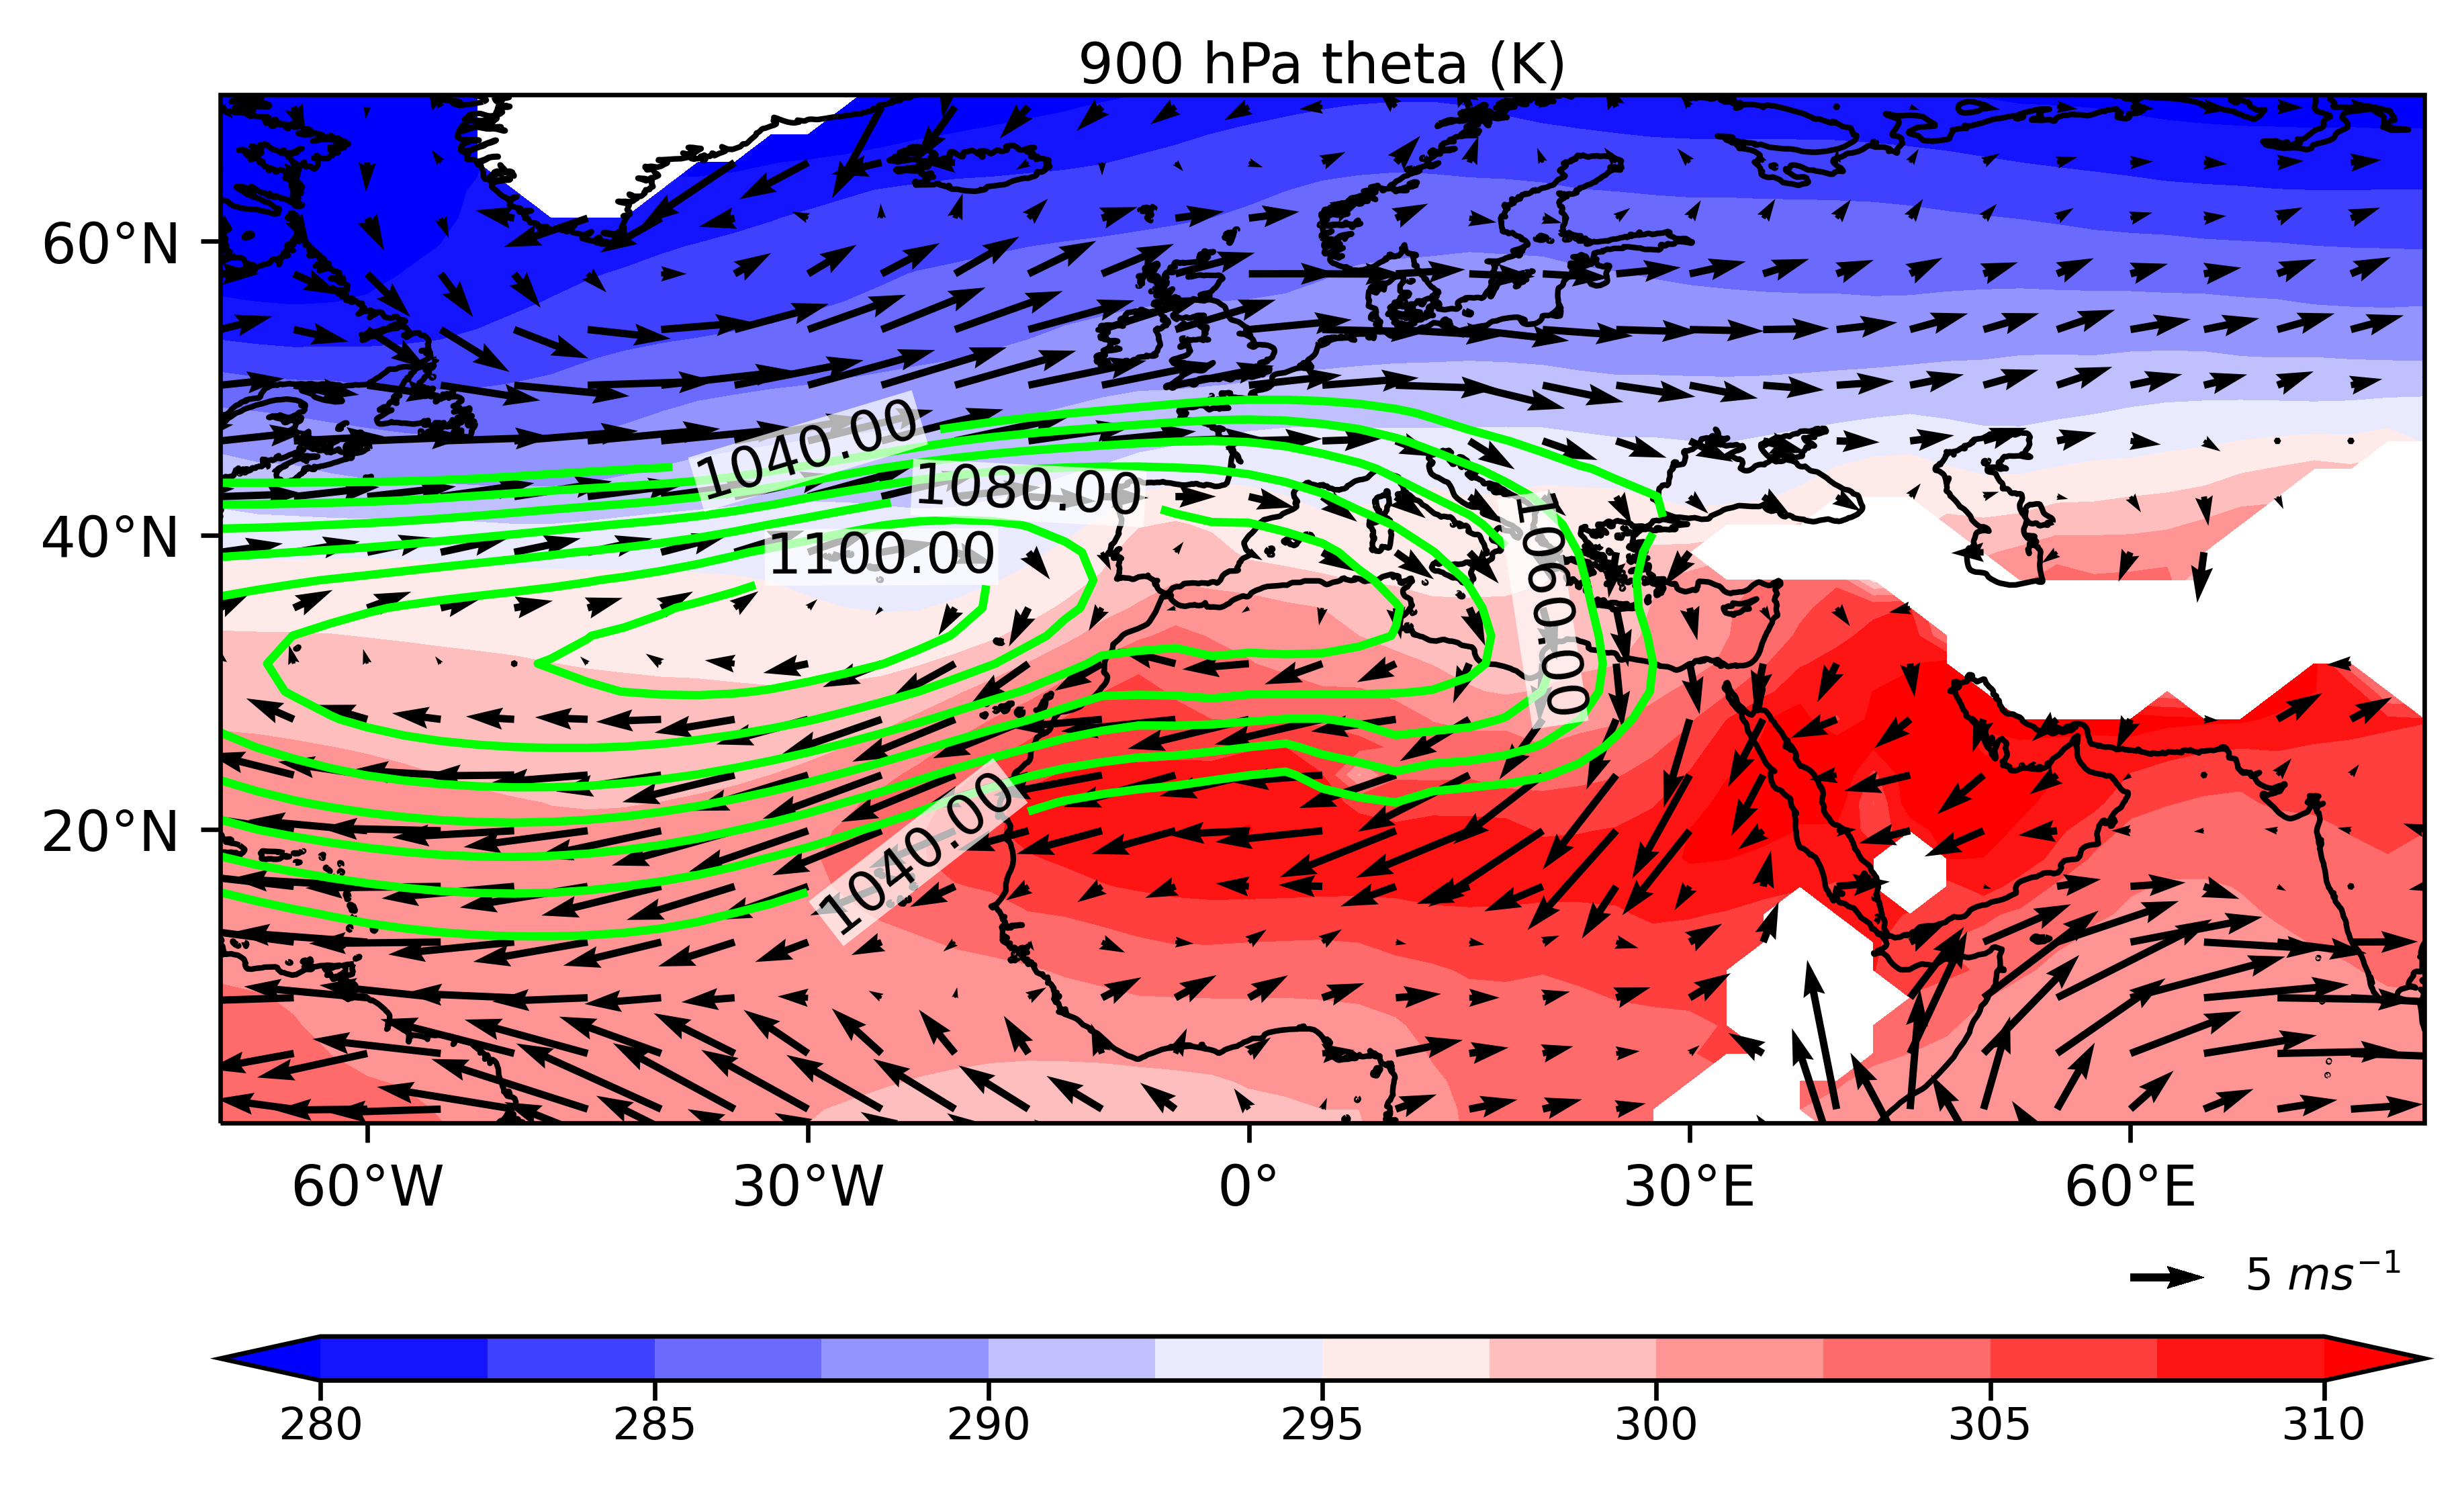

In [7]:
fig = plt.figure(figsize=(6, 6),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

  
ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())    

# minVal = -20
# maxVal = 20+2
# cint = 2
minVal = 280
maxVal = 310+2.5
cint = 2.5
intervals = np.arange(minVal, maxVal, cint)
vari=pot

line_intervals = np.array([1040,1050,1060,1070,1080,1090,1100])

phi_line=Z3.mean(dim='time')

u  =U
v  =V

ax1,CF =plot_phi(ax,vari.mean(dim='time'),intervals,phi_line,line_intervals,u.mean(dim='time'),\
                      v.mean(dim='time'))
ax1.set_title('900 hPa theta (K)',fontsize=10,pad=0.5)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=8,pad=1)